# Random Forest Model

In [289]:
rand_model = rf_model.fit(x_train_res, y_train_res)

In [290]:
print("OOB score", rf_model.oob_score_)

OOB score 0.9660546025610051


## The Random Forest model achieved an Out-of-Bag (OOB) validation score of 96%, 
## Indicating strong generalization performance in predicting customer churn on unseen data.

## Marketing and retention teams can confidently target high-risk customers.

## This enables proactive retention campaigns, reducing revenue loss.

## The high OOB score suggests low overfitting and strong model stability

# Stratified K-Fold for checking the variance Performance by the model

In [291]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

In [292]:
## Cross validation splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_result = cross_val_score(rf_model,x_train_res, y_train_res, scoring='accuracy', cv=cv)

In [293]:
for i, score in enumerate(rf_result, 1):
    print(f"Fold {i}: {score:.4f}")

Fold 1: 0.9601
Fold 2: 0.9692
Fold 3: 0.9632
Fold 4: 0.9710
Fold 5: 0.9716


In [294]:
print(f"The Average Stratified Kfold value of 5 fold is {rf_result.mean()*100:.2f} percent")

The Average Stratified Kfold value of 5 fold is 96.70 percent


## Both validation methods give almost identical performance.
## No major variance as Both OOB and CV difference is less than 1%, 
## Model confirms no overfitting

In [295]:
roc_auc_score(y_train_res, rf_model.oob_decision_function_[:,1])

0.993148806212901

## A ROC-AUC score of 99.3% means the model has a 99.3% chance of ranking a randomly selected churn customer higher than a randomly selected non-churn customer across all possible thresholds.

In [296]:
rand_score = rf_model.score(x_train_res, y_train_res)
rand_score*100

97.02826769751147

In [297]:
rand_score_pred = rf_model.score(x_test, y_test)
rand_score_pred*100

95.59971611071683

In [298]:
y_rand_pred = rf_model.predict(x_test)

In [299]:
feature_importance = pd.Series(rf_model.feature_importances_,index=x_train_res.columns).sort_values(ascending=False)

print(feature_importance)

Satisfaction Score                   4.886039e-01
Contract                             1.331930e-01
Number of Referrals                  6.496246e-02
Tenure in Months                     4.948388e-02
Payment Method_Credit Card           3.481317e-02
Monthly Charge                       2.714511e-02
Number of Dependents                 2.626771e-02
AddOn_Count                          2.525301e-02
Avg Monthly GB Download              2.060003e-02
Internet Type_Fiber Optic            1.787377e-02
Online Security                      1.733018e-02
Internet Service                     1.483414e-02
Premium Tech Support                 1.260232e-02
Age                                  9.575357e-03
Avg Monthly Long Distance Charges    4.937773e-03
Referred a Friend                    4.757860e-03
Internet Type_DSL                    4.556872e-03
Online Backup                        4.519317e-03
Married                              4.338230e-03
City_Grouped_Other                   3.963034e-03


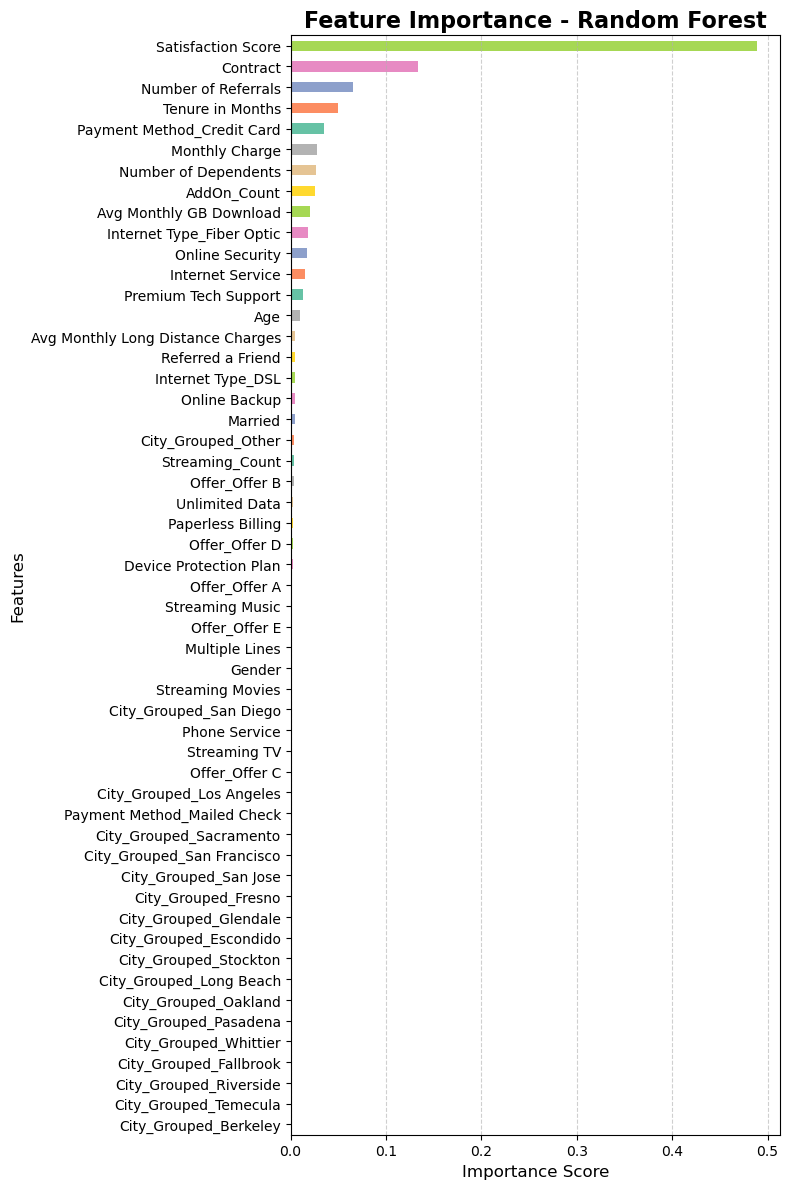

In [300]:
plt.figure(figsize=(8, 12))

feature_importance.sort_values().plot(kind='barh',color=plt.cm.Set2.colors)

plt.title("Feature Importance - Random Forest", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Strong Predictors of Churn (Top Features)
## Features contribute the most to the Random Forest model.
## --------------------------------------------------------------------------------------------------------------------------------

## Satisfaction Score: Highest importance.
## Customers with low satisfaction are very likely to churn.
## Interpretation: Customer satisfaction is the most critical factor influencing churn behaviour.
## --------------------------------------------------------------------------------------------------------------------------------

## Contract: Contract type strongly affects churn.
## Month-to-month customers churn more than long-term contracts.
## Interpretation: Customers with flexible contracts have a higher probability of leaving the service.
## -------------------------------------------------------------------------------------------------------------------------------

## Number of Referrals: Customers who refer others are more loyal.
## Interpretation: Referral behaviour reflects strong customer loyalty, reducing churn probability.
## ------------------------------------------------------------------------------------------------------------------------------

## Tenure in Months: Long-term customers rarely churn.
## Interpretation: Customer churn is significantly higher among new customers compared to long-term subscribers.
## =========================================================================

# Moderately Important Features
## These also influence churn but less strongly.

## Monthly Charge: Higher cost may increase churn.
## AddOn_Count: Customers using more services stay longer.
## --------------------------------------------------------------------------------------------------------------------------------
## Internet Type (Fiber Optic) Service quality differences affect churn.
## Online Security / Premium Tech Support: Value-added services reduce churn risk.
## Interpretation: Service usage patterns and value-added services contribute to customer retention by increasing dependency on the service ecosystem.
## =========================================================================

# Low Importance Features
## These have very little impact on churn prediction.
## Gender, City variables, Phone service, Streaming services
## Interpretation: Demographic and geographic variables have minimal impact on churn compared to service experience and customer engagement factors.
## -------------------------------------------------------------------------------------------------------------------------------

# SHAP for RandomForest

In [301]:
import shap

In [302]:
explainer_rf1 = shap.TreeExplainer(rf_model)
shap_val_rf1 = explainer_rf1(x_test)
shap_rf_od1 = shap_val_rf1[1]

In [303]:
print(type(shap_val_rf1))
print(np.shape(shap_val_rf1))

<class 'shap._explanation.Explanation'>
(1409, 53, 2)


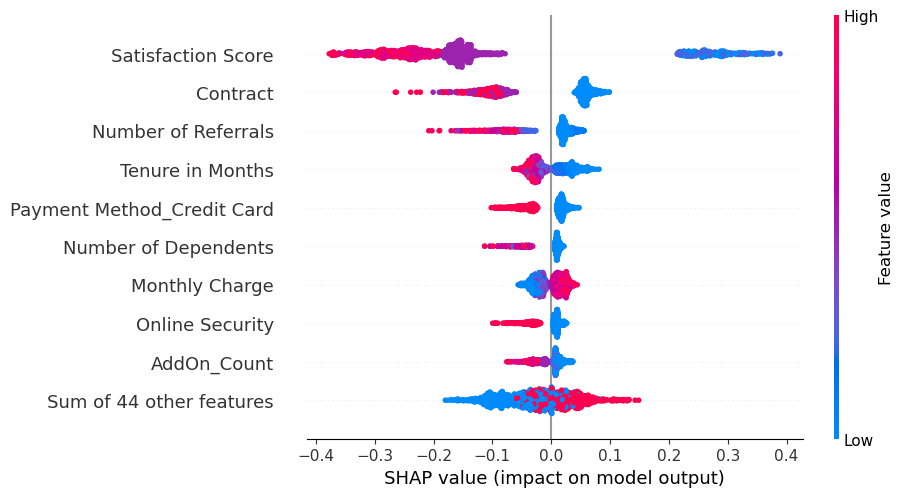

In [304]:
shap.plots.beeswarm(shap_val_rf1[...,1])

## The Contribution of Featurre Importance are clearly visible with SHAP (Blue - Low value of Feature) (Red -High value of Feature) 
## ---------------------------------------------------------------------------------------------------------------------------------
## Satisfaction Score (Most Important)
## High satisfaction SHAP values on the left and Low satisfaction SHAP values on the right
## Interpretation: Customers with low satisfaction scores significantly increase churn probability, while highly satisfied customers strongly reduce churn risk.
## Business Insight: Improving customer satisfaction is the most effective churn reduction strategy.
## --------------------------------------------------------------------------------------------------------------------------------
## Contract: Short contracts push SHAP values to the right
## Customers with month-to-month contracts are more likely to churn, while long-term contracts reduce churn probability.
## Number of Referrals High referrals SHAP values left
## Interpretation: Customers who refer more people are loyal customers with lower churn risk.
## --------------------------------------------------------------------------------------------------------------------------------
## Tenure in Months Low tenure right side 
## New customers are significantly more likely to churn compared to long-term customers.
## --------------------------------------------------------------------------------------------------------------------------------
## Payment Method – Credit Card
## Credit card usage pushes SHAP values left (lower churn).
## Customers paying via credit card show lower churn probability, likely due to automated payments and stronger service commitment.
## --------------------------------------------------------------------------------------------------------------------------------
## Monthly Charge: Higher charges move slightly to the right.
## Higher monthly bills moderately increase churn probability.
## --------------------------------------------------------------------------------------------------------------------------------
## Online Security: Customers without security services move right (higher churn).
## Customers who do not use security-related services are more likely to churn.
## AddOn_Count: More add-ons Customers using more additional services are less likely to churn due to stronger ecosystem dependency.

Max depth size 1
Train AUC ROC score  0.938994926310703
Test AUC ROC score  0.8941150636802812
Max depth size 2
Train AUC ROC score  0.9354916646532979
Test AUC ROC score  0.8961029734687024
Max depth size 3
Train AUC ROC score  0.9426189900942258
Test AUC ROC score  0.9022707897388205
Max depth size 4
Train AUC ROC score  0.952524764435854
Test AUC ROC score  0.9096631274380634
Max depth size 5
Train AUC ROC score  0.9609809132640735
Test AUC ROC score  0.9268296778526958
Max depth size 7
Train AUC ROC score  0.969437062092293
Test AUC ROC score  0.9326267793019711
Max depth size 10
Train AUC ROC score  0.9816380768301523
Test AUC ROC score  0.9400191170012142
Max depth size 15
Train AUC ROC score  0.9963759362164774
Test AUC ROC score  0.9386822186054923
Max depth size 20
Train AUC ROC score  0.999395989369413
Test AUC ROC score  0.942805290759255


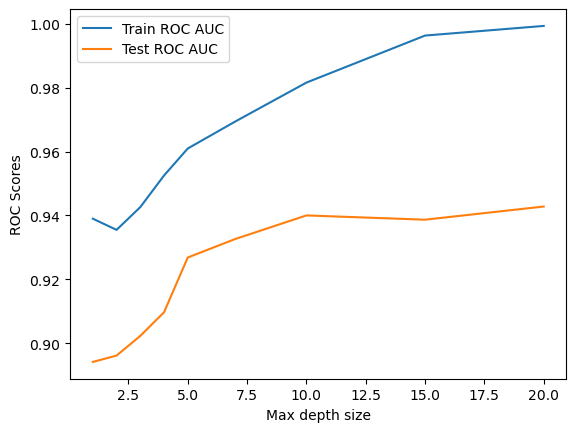

In [305]:
max_depth_size = [1,2,3,4,5,7,10,15,20]
train_roc_score = []
test_roc_score = []

for depth in max_depth_size:
    model = RandomForestClassifier(oob_score = True, random_state = 42, max_depth = depth)
    model.fit(x_train_res, y_train_res)
    train_pred = model.predict(x_train_res)
    test_pred = model.predict(x_test)
    roc_auc_train = roc_auc_score(y_train_res, train_pred)
    roc_auc_test = roc_auc_score(y_test, test_pred)
    train_roc_score.append(roc_auc_train)
    test_roc_score.append(roc_auc_test)
    print("Max depth size", depth)
    print("Train AUC ROC score ", roc_auc_train)
    print("Test AUC ROC score ", roc_auc_test)


plt.plot(max_depth_size, train_roc_score, label="Train ROC AUC")
plt.plot(max_depth_size, test_roc_score, label="Test ROC AUC")

plt.xlabel("Max depth size")
plt.ylabel("ROC Scores")

plt.legend()
plt.show()

## Max depth size at 7 to 10 is optimal ans with balanced without underfitting and overfitting
## Depth Max depth size 7 Train AUC ROC score  0.931
## Depth Max dpth size 10 Test AUC ROC score  0.936 (highest)
## This is your best generalization region, Model is powerful but not heavily overfitting.


# Evaluation of RandomForest Model

## Confusion Matrix of Random Forest

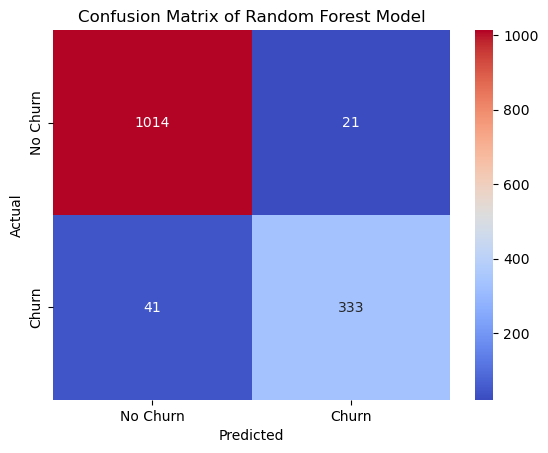

In [306]:
sb.heatmap( confusion_matrix(y_test,y_rand_pred), 
            annot=True, 
            fmt='d', 
            cmap='coolwarm',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Random Forest Model")
plt.show()

## Targeted 21 customers thinking they will churn
## But they actually would not. Marketing cost may waste
## 42 less than 21 predicting Churn as Non Churn is lare comparitively 
## Further Precision Recall Evaluation fills the gap

# Classification Report on Random Forest

In [307]:
rand_cl_rep = pd.DataFrame(classification_report(y_test, y_rand_pred, output_dict = True))
rand_cl_rep

,0,1,accuracy,macro avg,weighted avg
precision,0.961137,0.940678,0.955997,0.950908,0.955707
recall,0.979710,0.890374,0.955997,0.935042,0.955997
f1-score,0.970335,0.914835,0.955997,0.942585,0.955603
support,1035.000000,374.000000,0.955997,1409.000000,1409.000000


## The Random Forest model is highly confident in predicting churn, with 94% precision.

## It generates fewer false alarms, ensuring efficient use of retention budgets.

## An F1-score of 91% reflects a strong balance between precision and recall.

## However, slightly lower recall indicates that some churners may go undetected, posing a potential revenue risk.


In [308]:
y_train_rfprob = rf_model.predict_proba(x_train_res)
y_test_rfprob = rf_model.predict_proba(x_test)

In [309]:
fprf, tprf, threshold_rf = roc_curve(y_test,y_test_rfprob[:,1]) 

In [310]:
prec_rf , recall_rf , thredh_rf = precision_recall_curve(y_test,y_test_rfprob[:,1])

In [311]:
auc_rf = auc(fprf, tprf)

Text(0.5, 1.0, 'Receiver Operating Characteristic Curve Random Forest')

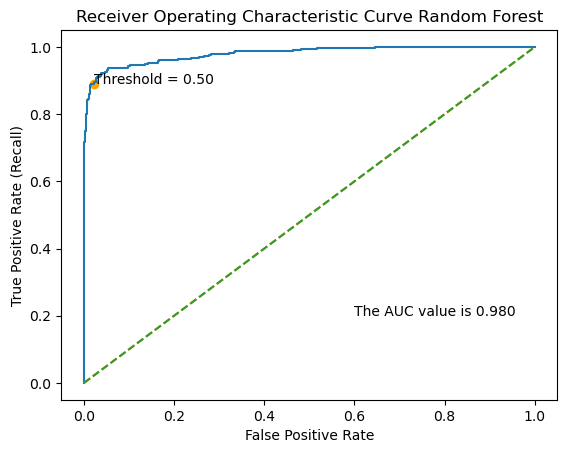

In [312]:
plt.figure()
idx = np.argmin(np.abs(threshold_rf - 0.5))

plt.plot(fprf, tprf)
plt.scatter(fprf[idx], tprf[idx], color ="orange")
plt.text(fprf[idx],tprf[idx], f"Threshold = {threshold_rf[idx]:.2f}")
plt.plot(([0,0],[1,1]),linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")

plt.text(0.6, 0.2, f"The AUC value is {auc_rf:.3f}")
plt.title("Receiver Operating Characteristic Curve Random Forest")


## As the decision threshold decreases, the model captures more actual churners (higher TPR), but at the cost of incorrectly flagging more non-churn customers as churn (higher FPR)
## AUC with 98 percent states that the model separates churn vs non-churn very well High recall and Very low false alarms

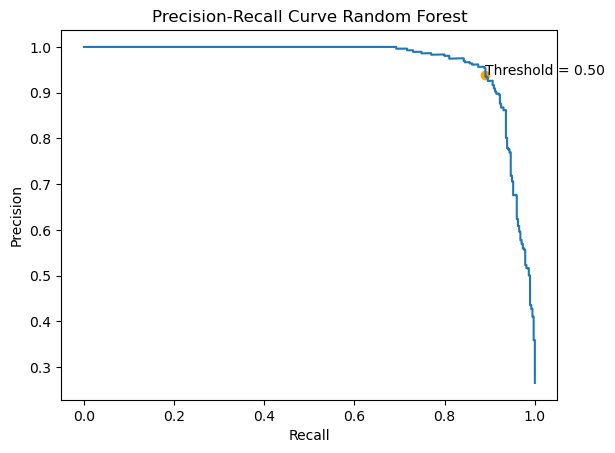

In [313]:
plt.figure()

idx = np.argmin(np.abs(thredh_rf - 0.5))

plt.plot(recall_rf, prec_rf)

plt.scatter(recall_rf[idx], prec_rf[idx], marker ="o", color ="orange")
plt.text(recall_rf[idx], prec_rf[idx],f"Threshold = {thredh_rf[idx]:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Random Forest")

plt.show()

## The model maintains very high precision for a large range of recall values, indicating strong separation between classes. 
## Precision drops only when recall approaches 1, meaning false positives increase when the threshold becomes too low.

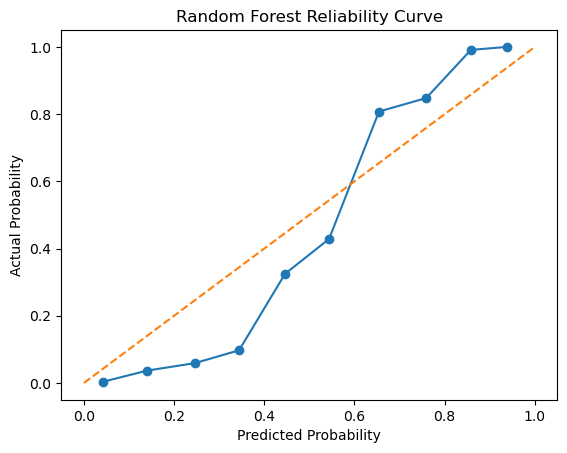

In [314]:
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_test_rfprob[:,1], n_bins=10)

plt.plot(prob_pred_rf, prob_true_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Random Forest Reliability Curve")
plt.show()

## The reliability curve indicates that the Random Forest model is reasonably well calibrated, especially for high churn probabilities. 
## While the model slightly underestimates churn risk in the mid-probability range, it accurately identifies high-risk customers, making it useful for targeted churn prevention strategies.

In [315]:
print(brier_score_loss(y_test,y_test_rfprob[:,1]))

0.0486147167602099


## The model achieved a Brier Score of 0.0486, indicating excellent probability calibration. 
## This means the predicted churn probabilities closely align with actual outcomes, making the model reliable for probability-based decision making such as identifying high-risk customers for retention campaigns.